# A3 - Segmentação de Clientes de Varejo

Orientador(es): Joberto Martins e Arthur Kronbauer

Unidade Curricular (UC): Inteligência 

Integrantes:
- Bianca (RA:)
- Edioelson Júnior A. B. Teixeira (1272318423)
- Duilio (RA:)
-

Objetivo: Criar um sistema capaz de segmentar os clientes de um varejo.

Algoritmos utilizados:
- K-Means Clustering
- DBSCAN

Dataset:
- [Mall Customers Dataset](https://www.kaggle.com/datasets/simtoor/mall-customers/data)



## 1. Introdução e objetivo do projeto

(pessoa 1 completar)

- qual é o problema do projeto;
- o que é segmentação de clientes;
- por que isso é útil para empresas de varejo/supermercado;
- qual é o objetivo da aplicação.

## 2. Descrição do dataset

(pessoa 1 completar)

explicar as colunas do dataset:
- CustomerID;
- Gender;
- Age;
- Annual Income (k$);
- Spending Score (1-100).

## Bibliotecas utilizadas
Para o desenvolvimento do projeto foram utilizadas as seguintes bibliotecas Python:
- [`pandas`](https://pandas.pydata.org/)
- [`numpy`](https://numpy.org/)
- [`matplotlib`](https://matplotlib.org/)
- [`sklearn`](https://scikit-learn.org/stable/)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

## Dataset e verificações iniciais
O dataset utilizado para o projeto foi o [Mall Customers Dataset](https://www.kaggle.com/datasets/simtoor/mall-customers/data).

- Verificações iniciais: não há valores nulos nem duplicados relevantes; CustomerID foi ignorado por não agregar informação para segmentação.

In [27]:
mall_customers_df = pd.read_csv("../data/Mall_Customers.csv").copy()

print("\n---------------------------- MALL CUSTOMERS DATASET ORIGINAL ----------------------------\n")
display(mall_customers_df)

print(f"\n\nO DATASET ORIGINAL POSSUI {mall_customers_df.shape[0]} LINHAS E {mall_customers_df.shape[1]} COLUNAS.")

print("\n\nVALORES NULOS POR COLUNA:\n")
display(mall_customers_df.isnull().sum())

print(f"\n\nQUANTIDADE DE VALORES DUPLICADOS POR COLUNA:\n\n{mall_customers_df.isnull().sum()}")

print("\n\nINFORMAÇÕES GERAIS:\n")
mall_customers_df.info()


---------------------------- MALL CUSTOMERS DATASET ORIGINAL ----------------------------



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18




O DATASET ORIGINAL POSSUI 200 LINHAS E 5 COLUNAS.


VALORES NULOS POR COLUNA:



CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64



QUANTIDADE DE VALORES DUPLICADOS POR COLUNA:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


INFORMAÇÕES GERAIS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


- Variáveis escolhidas para agrupamento: "Annual Income (k$)" e "Spending Score (1-100)" — justificativa: representam capacidade de compra e comportamento de gasto, mais diretamente acionáveis para ações de marketing.

In [19]:
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
print("\nResumo estatístico (numérico):\n", mall_customers_df[numeric_cols].describe())


Resumo estatístico (numérico):
               Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


## Análise exploratória dos dados

Nesta seção, criar gráficos como:
- quantidade de clientes por gênero;
- distribuição de idade;
- distribuição de renda anual;
- distribuição do spending score;
- relação entre renda anual e spending score.



### Contagem por genêro
Resumo geral
- Uso de Gender: empregado apenas para análise visual (colorização) e compreensão do perfil; não foi incluído no K-Means para evitar mistura de variáveis categóricas sem tratamento adicional.

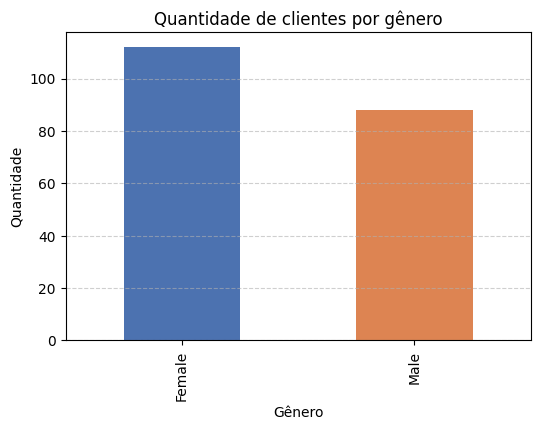

In [29]:
plt.figure(figsize=(6,4))
mall_customers_df["Gender"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Quantidade de clientes por gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## Distribuições
- Utilizams o gráfico de Histogramas para identificar a distribuição das variáveis. Conclusão: ...

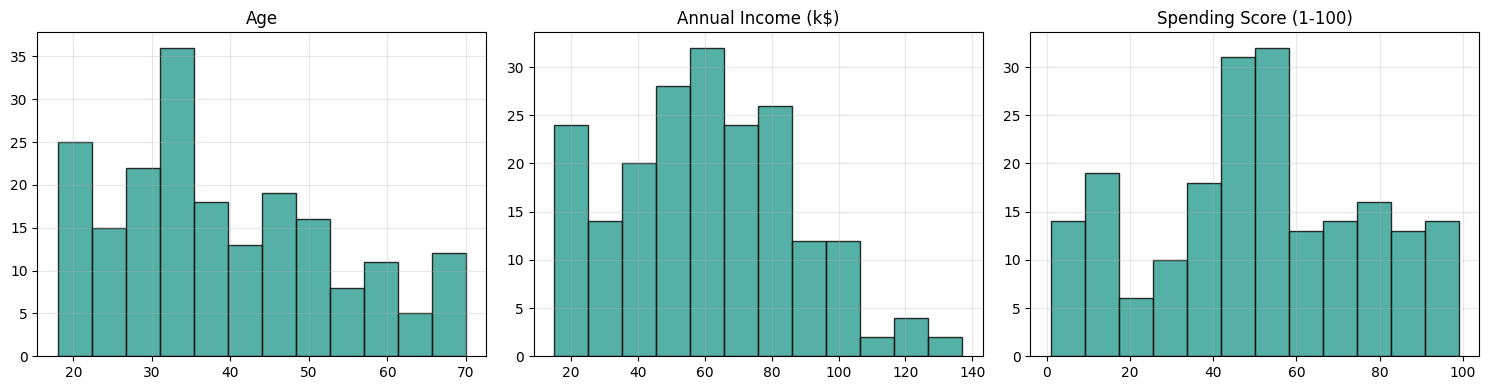

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(mall_customers_df[col], bins=12, color="#2A9D8F", edgecolor="k", alpha=0.8)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Outliers
Utilizamos o gráfico de Boxplots para identificar outliers. conclusão...

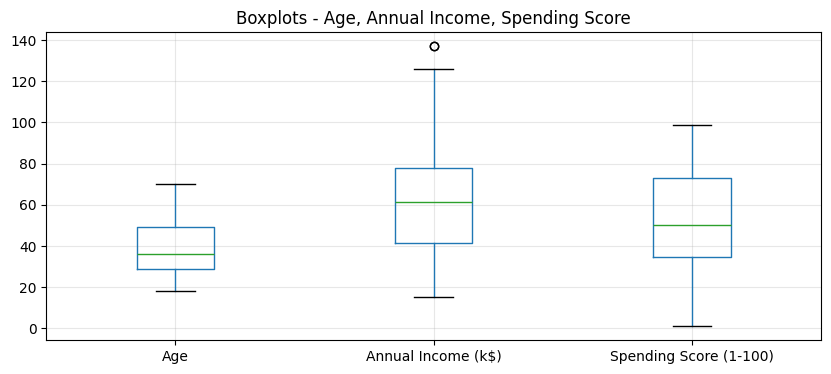

In [31]:
# Boxplots para identificar outliers
plt.figure(figsize=(10,4))
mall_customers_df[numeric_cols].boxplot()
plt.title("Boxplots - Age, Annual Income, Spending Score")
plt.grid(alpha=0.3)
plt.show()

## Relação entre "renda anual" e "spending score"
- Descricão e conclusão

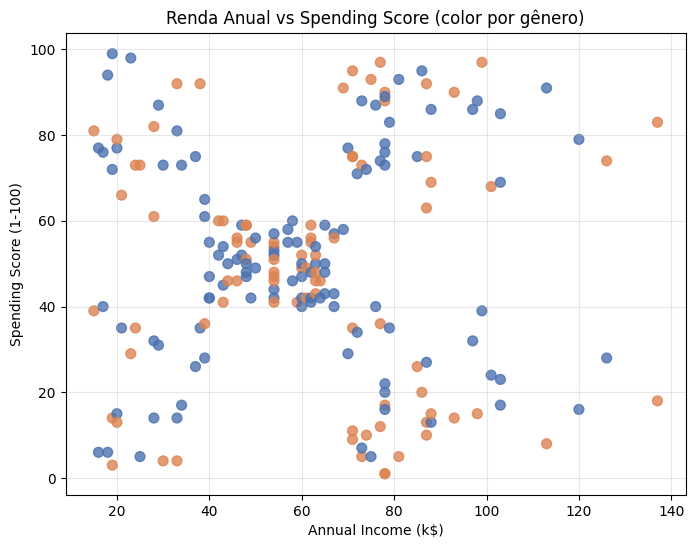

In [35]:
# Relação entre renda anual e spending score (color por gênero)
colors = mall_customers_df["Gender"].map({"Male":"#DD8452","Female":"#4C72B0"})
plt.figure(figsize=(8,6))
plt.scatter(mall_customers_df["Annual Income (k$)"], mall_customers_df["Spending Score (1-100)"], c=colors, alpha=0.8, s=50)
plt.title("Renda Anual vs Spending Score (color por gênero)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.3)
plt.show()

## Correlação entre variáveis numéricas
- Descrição e conclusão.

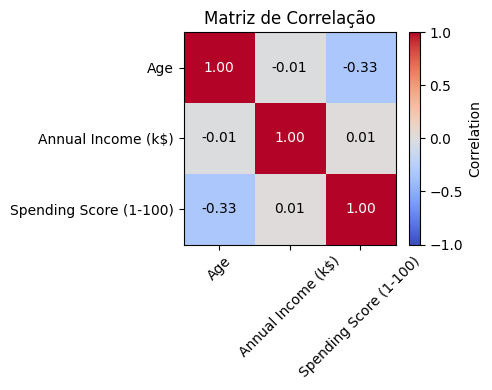

In [36]:
# Matriz de correlação entre variáveis numéricas
corr = mall_customers_df[numeric_cols].corr()
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", color="w" if abs(corr.iloc[i,j])>0.5 else "k")
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

In [ ]:
## 3. Decisões tomadas e conclusões da EDA


- Padronização: aplicado StandardScaler antes do K-Means para equalizar escala e evitar pesos indevidos por magnitude.
- Identificação de outliers: boxplots usados para inspeção visual; nenhum tratamento automático aplicado — mantidos para preservar padrões naturais dos clientes.
- Correlações: renda e spending score têm correlação praticamente nula; idade tem correlação negativa moderada com spending score (~-0.33). Isso reforça a escolha de renda vs. gasto como eixo principal da segmentação.
- Avaliação de K-Means: Método do cotovelo e Silhouette Score foram utilizados; K = 5 selecionado por melhor balanceamento entre inércia e separação.
- Conclusões práticas: os clusters obtidos permitem distinguir perfis (ex.: alto gasto/alta renda, baixo gasto/alta renda, alto gasto/baixa renda, etc.), úteis para campanhas segmentadas. Próximos passos sugeridos: testar DBSCAN para detectar ruídos/outliers, avaliar inclusão de gênero ou idade em modelos alternativos e validar campanhas com dados reais.

In [37]:
X=mall_customers_df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Para começar o K-Means, foram escolhidas duas colunas principais: renda anual(Annual Income (k$)) e pontuação de gasto(Spending Score (1-100)). Essas informações ajudam a separar clientes de acordo com quanto eles ganham e quanto costumam gastar.


## 4. Pré-processamento dos dados

ja fiz a seleção das variáveis para agrupamento e padronização com StandardScaler

pessoa 3 pode complementar com:
- explicação sobre remoção/ignorância de CustomerID;
- verificação de dados duplicados;
- tratamento da variável Gender, caso o grupo decida usar;
- justificativa das variáveis escolhidas.

In [41]:
# Padronização dos dados

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [40]:
# Transformando os dados padronizados em uma tabela para visualizar melhor

X_scaled_df=pd.DataFrame(
    X_scaled,
    columns=["Renda Anual Padronizada", "Pontuação de Gasto Padronizada"]
)
X_scaled_df.head()

,Renda Anual Padronizada,Pontuação de Gasto Padronizada
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


A padronização foi feita com o StandardScaler. Ela deixa as variáveis em uma escala parecida.

Isso é importante porque o K-Means calcula distância entre os pontos. Se uma coluna tiver valores muito maiores que a outra, ela pode acabar pesando mais no resultado.


## 5. Segmentação com K-Means

Nesta etapa foi aplicado o K-Means, que separa os clientes em grupos parecidos de acordo com as variáveis escolhidas.

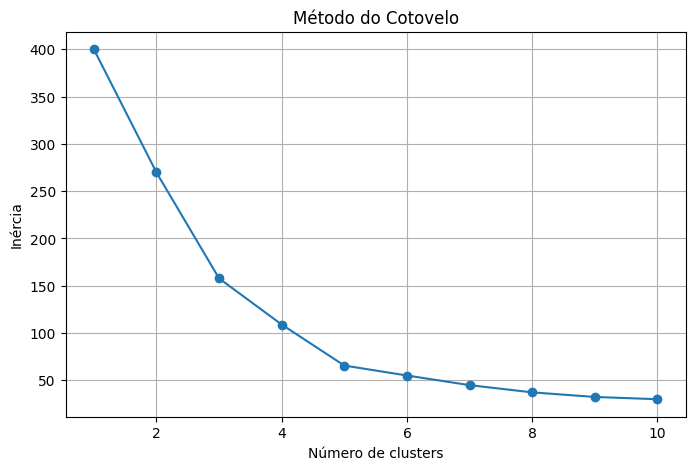

In [42]:
# Método do cotovelo para escolher o número de clusters

inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()

O método do cotovelo foi usado para ajudar na escolha da quantidade de grupos. A ideia é olhar o ponto em que a queda da inércia começa a ficar menor. Esse ponto ajuda a decidir um valor de K.


In [43]:
# Cálculo do Silhouette Score para diferentes valores de K

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k} | Silhouette Score = {score:.3f}")

K = 2 | Silhouette Score = 0.321
K = 3 | Silhouette Score = 0.467
K = 4 | Silhouette Score = 0.494
K = 5 | Silhouette Score = 0.555
K = 6 | Silhouette Score = 0.540
K = 7 | Silhouette Score = 0.528
K = 8 | Silhouette Score = 0.455
K = 9 | Silhouette Score = 0.457
K = 10 | Silhouette Score = 0.443


O Silhouette Score foi utilizado como métrica para avaliar a qualidade dos agrupamentos. O valor varia de -1 a 1. Quanto mais próximo de 1, melhor a separação entre os clusters.

O valor K = 5 foi escolhido porque apresentou o melhor Silhouette Score entre os valores testados, indicando uma boa separação entre os grupos.

In [45]:
# Aplicação do K-Means com 5 clusters

kmeans=KMeans(n_clusters=5, random_state=42, n_init=10)

mall_customers_df["Cluster_KMeans"]=kmeans.fit_predict(X_scaled)

mall_customers_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_KMeans
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Após a análise do método do cotovelo e do Silhouette Score, foi escolhido o valor K = 5 para segmentar os clientes em cinco grupos.

In [46]:
# Quantidade de clientes em cada grupo

mall_customers_df["Cluster_KMeans"].value_counts().sort_index()

Cluster_KMeans
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Essa contagem mostra quantos clientes ficaram em cada grupo criado pelo K-Means.


In [47]:
# Média de renda anual e pontuação de gasto por grupo

mall_customers_df.groupby("Cluster_KMeans")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster_KMeans,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


As médias de renda anual e pontuação de gasto ajudam a entender o perfil de cada grupo. Com isso, dá para dar um nome mais fácil para cada segmento de cliente.


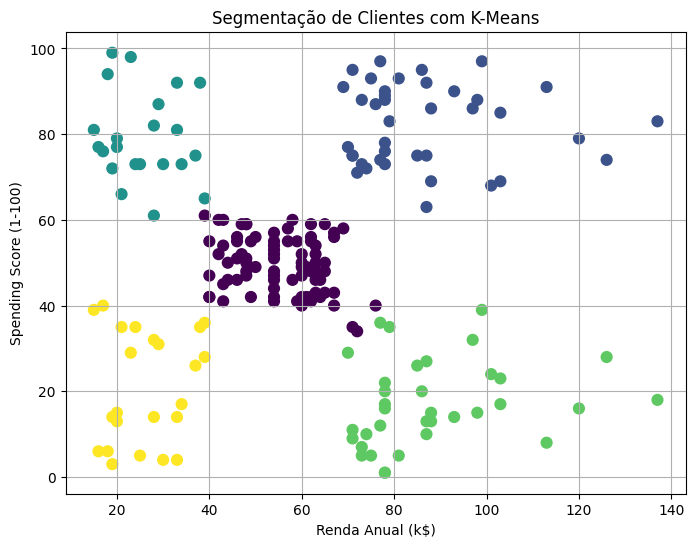

In [48]:
# Visualização dos clusters gerados pelo K-Means

plt.figure(figsize=(8, 6))
plt.scatter(
    mall_customers_df["Annual Income (k$)"],
    mall_customers_df["Spending Score (1-100)"],
    c=mall_customers_df["Cluster_KMeans"],
    s=60
)

plt.title("Segmentação de Clientes com K-Means")
plt.xlabel("Renda Anual (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)
plt.show()

O gráfico mostra a segmentação dos clientes com base na renda anual e na pontuação de gasto. Cada cor representa um grupo diferente identificado pelo algoritmo K-Means.

## 6. Interpretação dos grupos do K-Means

Com base nas médias de renda anual e pontuação de gasto, os grupos foram interpretados da seguinte forma:

Grupo 0: clientes com renda média e gasto médio.
Grupo 1: clientes com alta renda e alto gasto.
Grupo 2: clientes com baixa renda e alto gasto.
Grupo 3: clientes com alta renda e baixo gasto.
Grupo 4: clientes com baixa renda e baixo gasto.

Essa divisão pode ajudar uma empresa de varejo a pensar em campanhas diferentes para cada tipo de cliente.

## 7. Segmentação com DBSCAN
(pessoa 5 completar)

aplicar o algoritmo DBSCAN:
- testar valores de eps;
- testar valores de min_samples;
- criar os clusters;
- identificar ruídos/outliers;
- visualizar os grupos.

## 8. Comparação entre K-Means e DBSCAN

(pessoa 5 completar)
comparar:
- número de grupos encontrados;
- métricas de desempenho;
- facilidade de interpretação;
- presença de ruídos/outliers;
- vantagens e desvantagens de cada algoritmo.

## 9. Aplicação prática para campanhas de marketing
(pessoa 6 completar)

criar uma função simples para:
- receber os dados de um novo cliente;
- classificar o cliente em um grupo;
- mostrar o perfil do grupo;
- sugerir uma campanha de marketing personalizada.

## 10. Conclusão

(grupo completar)

Nesta seção, explicar:
- qual algoritmo funcionou melhor;
- como os grupos podem ajudar uma empresa de varejo;
- limitações do projeto;
- possíveis melhorias futuras.